# Superstore Sales Dashboard

## Business Problem

The objective of this project is to analyze a retail company's sales performance and identify the products, categories, and regions that contribute the most to revenue and profitability.

The analysis aims to support business decision-making by identifying sales trends, high-performing product categories, and opportunities to improve profitability.

In [ ]:
# Download Superstore dataset from Kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
Path to dataset files: /kaggle/input/superstore-dataset-final


In [ ]:
import os

for archivo in os.listdir(path):
    print(archivo)

Sample - Superstore.csv


In [ ]:
#set the stage
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    path + "/Sample - Superstore.csv",
    encoding="latin1"
)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Dataset overview
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Dataset Description

The dataset contains transactional information from a retail company, including customer orders, sales, profits, discounts, products, and geographic information.

Main variables include:

- Sales
- Profit
- Quantity
- Discount
- Category
- Sub-Category
- Region
- Customer Information
- Order Date

In [ ]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## Data Exploration

Before performing any analysis, the dataset is explored to understand its structure, identify missing values, verify data types, and obtain descriptive statistics.

This step ensures that the data is complete and suitable for analysis.

In [ ]:
# Statistical summary
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
# Missing values
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

## Key Performance Indicators

The following KPIs provide an overall view of the company's performance:

- Total Sales
- Total Profit
- Total Number of Orders
- Average Order Value

These indicators summarize the overall business performance before performing a deeper analysis.

In [ ]:
#Sales
total_sales = df["Sales"].sum()

print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,297,200.86


In [ ]:
#Profit
total_profit = df["Profit"].sum()

print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $286,397.02


In [ ]:
#Orders
total_orders = df["Order ID"].nunique()

print(f"Total Orders: {total_orders}")

Total Orders: 5009


In [ ]:
#Avarage order
average_order = df["Sales"].mean()

print(f"Average Order Value: ${average_order:.2f}")

Average Order Value: $229.86


## Sales Analysis by Category

This visualization compares total sales across the company's product categories.

Understanding which categories generate the highest revenue helps identify the main drivers of business growth and supports inventory and marketing decisions.

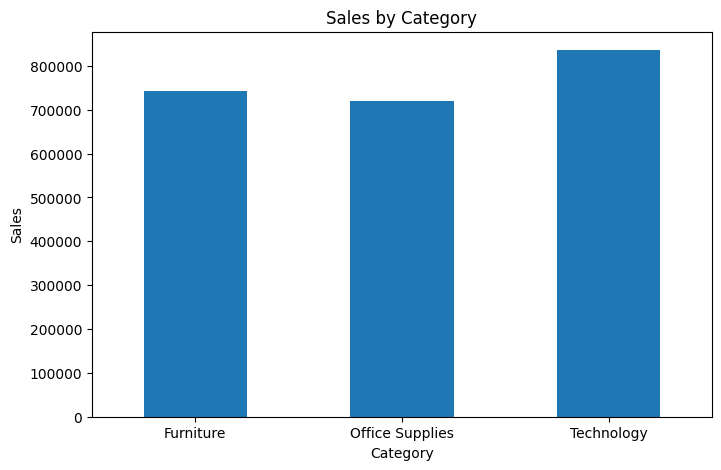

In [ ]:
sales_category = df.groupby("Category")["Sales"].sum()

sales_category.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.show()

### Business Insight

Technology generated the highest sales, indicating that it is one of the company's strongest revenue sources. Maintaining investment in this category may help sustain future growth.

## Profitability by Category

High sales do not always translate into high profitability.

This analysis compares the profit generated by each category to identify which business areas contribute the most to financial performance.

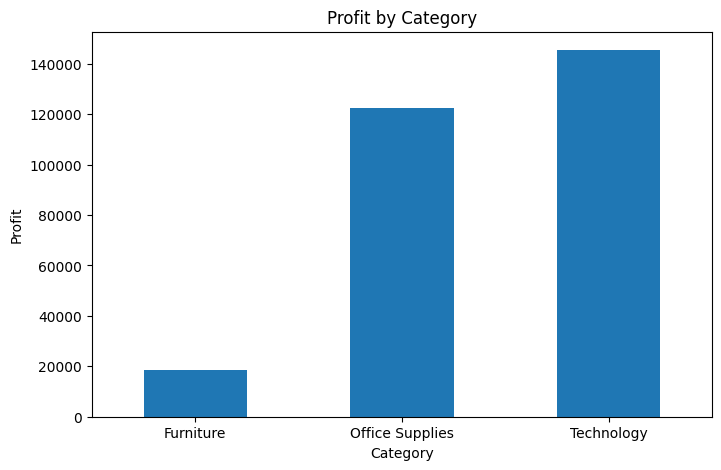

In [ ]:
profit_category = df.groupby("Category")["Profit"].sum()

profit_category.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.xticks(rotation=0)

plt.show()

### Business Insight

Although some categories generate high sales, their profitability differs considerably. Decision-makers should evaluate both revenue and profit when defining business strategies.

## Regional Sales Performance

This analysis evaluates sales performance across different geographic regions.

Regional comparisons help identify high-performing markets and areas with potential for future growth.

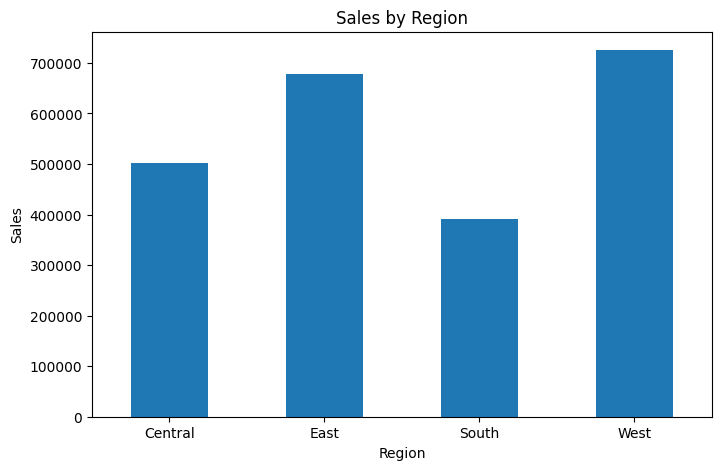

In [ ]:
sales_region = df.groupby("Region")["Sales"].sum()

sales_region.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.show()

## Top Performing Products

This visualization identifies the products with the highest sales.

Knowing which products generate the most revenue helps prioritize inventory, promotions, and purchasing decisions.

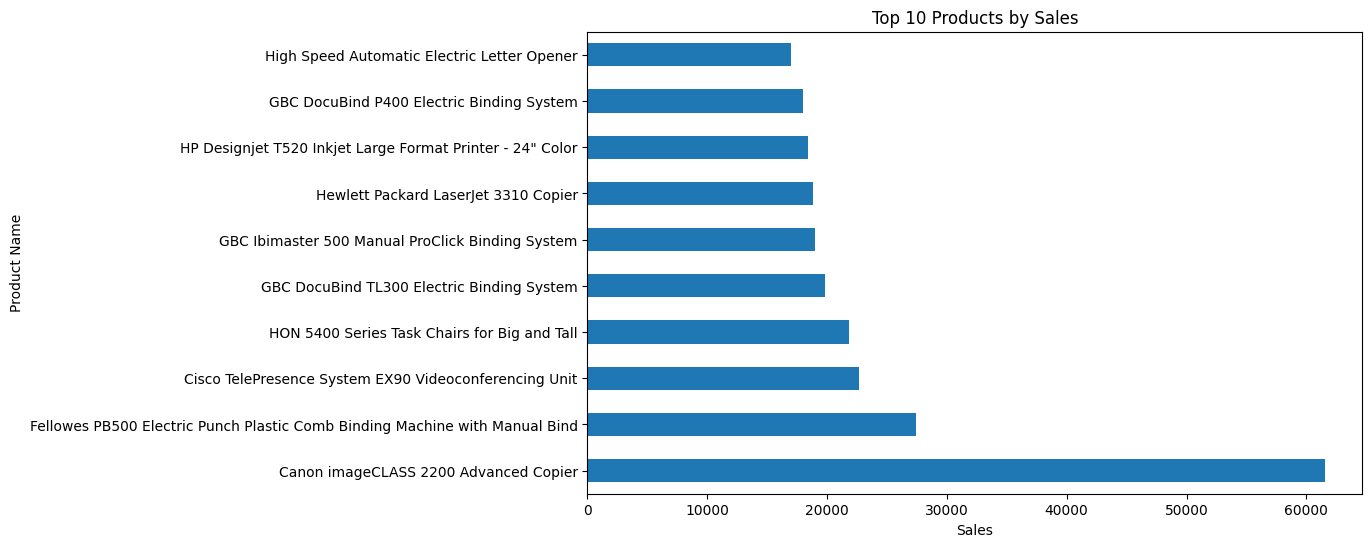

In [ ]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")

plt.show()

### Business Insight

A relatively small number of products generate a significant portion of total sales, suggesting opportunities to optimize inventory and promotional strategies.

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

## Monthly Sales Trend

Sales are analyzed over time to identify seasonal patterns and long-term business trends.

Recognizing periods of high and low demand supports forecasting and operational planning.

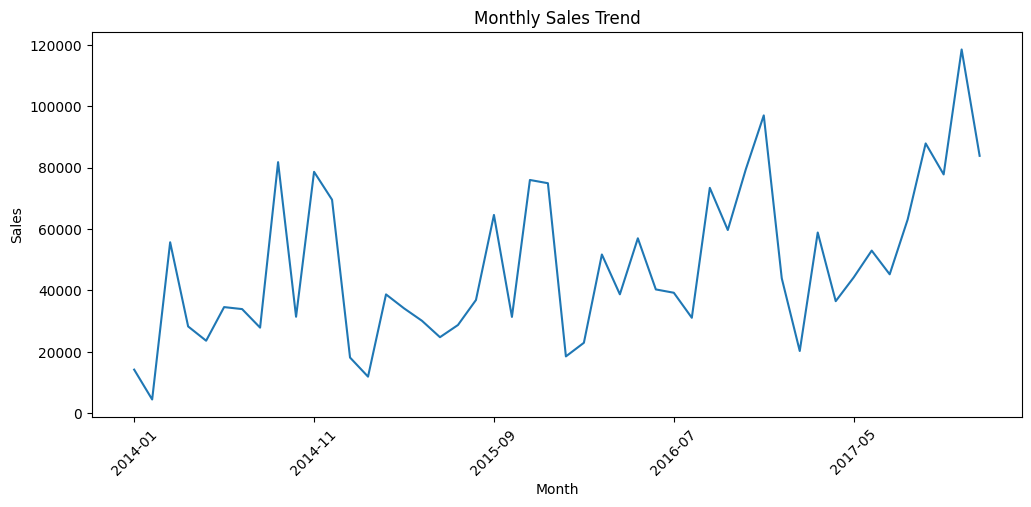

In [ ]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
      .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales.plot(
    figsize=(12,5)
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

### Business Insight

Sales fluctuate throughout the year, indicating possible seasonal demand patterns. These trends can help improve inventory management and sales forecasting.

# Conclusions

The analysis provides a general overview of the company's sales performance and highlights important differences across product categories, regions, and time.

### Key Findings

- Technology generated the highest sales.
- Profitability varies across categories.
- Regional performance is uneven.
- A limited number of products account for a large share of total revenue.
- Sales exhibit noticeable seasonal fluctuations.

### Future Work

Future versions of this project may include:

- Customer segmentation
- Profit forecasting
- Predictive sales modeling
- Interactive Power BI dashboards
- Machine Learning models for demand prediction